# Testing
### Migrationsstatus der Wohnbevölkerung

Beschreibung
Diese Daten beschreiben den Migrationsstatus der Wohnbevölkerung der Stadt Zürich nach Alter und Stadtquartier. Sie basieren nicht auf dem Bevölkerungsregister der Stadt Zürich, sondern aus den Zielpersonendaten der Strukturerhebung des Bundesamtes für Statistik.

In der Rubrik Bemerkungen finden Sie weitere Angaben, die bei der Datenauswertung beachtet werden müssen, weil es sich um Stichprobedaten handelt.

Datum: 26.02.2026


Dataset auf PROD-Datakatalog: Link https://data.stadt-zuerich.ch/dataset/bfs_bev_migrationsstatus_alter_quartier_seit2010_od5307

Dataset auf INTEG-Datakatalog: Link https://data.integ.stadt-zuerich.ch/dataset/int_dwh_bfs_bev_migrationsstatus_alter_quartier_seit2010_od5307

### Importiere die notwendigen Packages

In [116]:
#%pip install geopandas altair fiona requests folium mplleaflet contextily seaborn datetime plotly leafmap

In [117]:
import altair as alt
import datetime
import folium 
import geopandas as gpd
import io
from IPython.display import Markdown as md
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
#import pivottablejs
#from pivottablejs import pivot_ui
import plotly.express as px
import requests
import seaborn as sns

Welche Python, Altair und Seaborn Version wird verwendet?

In [118]:
#base env 2025: Python 3.11.7
import ipykernel
print(ipykernel.__version__)

import sys
import platform
print("Python-Version:", sys.version)
print("Python-Implementierung:", platform.python_implementation())
print("Python-Build:", platform.python_build())
print("Python-Compiler:", platform.python_compiler())

print("Altair-Version:", alt.__version__)
print("Seaborn-Version:", sns.__version__)

6.29.3
Python-Version: 3.11.8 | packaged by Anaconda, Inc. | (main, Feb 26 2024, 21:34:05) [MSC v.1916 64 bit (AMD64)]
Python-Implementierung: CPython
Python-Build: ('main', 'Feb 26 2024 21:34:05')
Python-Compiler: MSC v.1916 64 bit (AMD64)
Altair-Version: 5.0.1
Seaborn-Version: 0.12.2


Importiere die eigenen Funktionen, die unter ../0_scripts abegelegt sind:

In [119]:
import sys
sys.path.append('../0_scripts')

import my_py_dataviz_functions as mypy_dv
import my_py_dataloading_functions as mypy_dl

In [120]:
SSL_VERIFY = False
# evtl. SSL_VERIFY auf False setzen wenn die Verbindung zu https://www.gemeinderat-zuerich.ch nicht klappt (z.B. wegen Proxy)
# Um die SSL Verifikation auszustellen, bitte die nächste Zeile einkommentieren ("#" entfernen)
# SSL_VERIFY = False

In [121]:
if not SSL_VERIFY:
    import urllib3
    urllib3.disable_warnings()

### Settings
Definiere Settings. 
Hier das Zahlenformat von Float-Werten (z.B. *'{:,.2f}'.format* mit Komma als Tausenderzeichen)

In [122]:
#pd.options.display.float_format = lambda x : '{:,.1f}'.format(x) if (np.isnan(x) | np.isinf(x)) else '{:,.0f}'.format(x) if int(x) == x else '{:,.1f}'.format(x)
pd.options.display.float_format = '{:.0f}'.format
pd.set_option('display.width', 100)
pd.set_option('display.max_columns', 15)

#### Paletten aus Zuericolors
Die Farbwerte habe ich aus R ausgelesen. Siehe dazu: `G:\sszsim\myR\zuericolors4python`

In [123]:
# Quantitative Paletten
zuericolors_qual12 = ["#3431DE", "#0A8DF6", "#23C3F1", "#7B4FB7", "#DB247D", "#FB737E", "#007C78", "#1F9E31", "#99C32E", "#9A5B01", "#FF720C", "#FBB900"]
zuericolors_qual12br = ["#5D4BFE", "#4AA9FF", "#55FFFF", "#986AD5", "#FC4C99", "#FF919A", "#349894", "#44B14A", "#B7E14E", "#B97624", "#FF7231", "#FFD736"]
zuericolors_qual12da= ["#0017BF", "#0072D7", "#00A5D2", "#5E359A", "#BA0062", "#DA5563", "#00615D", "#00770F", "#7BA600", "#7B4100", "#DC5500", "#DA9C00"]
# Divergente Paletten
zuericolors_div9val  =  ["#A30059", "#DB247D", "#FF579E", "#FFA8D0", "#E4E0DF", "#A8DBB1", "#55BC5D", "#1F9E31", "#10652A"] 
zuericolors_div9ntr  =  ["#782600", "#CC4309", "#FF720C", "#FFBC88", "#E4E0DF", "#AECBFF", "#6B8EFF", "#3B51FF", "#2F2ABB"] 
# Geschlechter Paletten
zuericolors_gender3  =  ["#349894", "#FFD736", "#986AD5"] 
zuericolors_gender6origin  =  ["#00615D", "#349894", "#DA9C00", "#FFD736", "#5E359A", "#986AD5"] 
zuericolors_gender5wedding  =  ["#349894", "#FFD736", "#3431DE", "#B8B8B8", "#D6D6D6"] 
# Sequenzielle Paletten
zuericolors_seq9blu  =  ["#CADEFF", "#AEC2FF", "#93A6FF", "#778AFF", "#5B6EFF", "#4D59E2", "#3E44C5", "#302FA7", "#211A8A"] 
zuericolors_seq9red  =  ["#FED2EE", "#FEAED6", "#F589BE", "#F165A5", "#ED408D", "#D1307B", "#B52069", "#991056", "#7D0044"] 
zuericolors_seq9grn  =  ["#CFEED8", "#A8E0B3", "#81D18F", "#5BC36A", "#34B446", "#2A9A3C", "#208032", "#166529", "#0C4B1F"] 
zuericolors_seq9brn  =  ["#FCDDBB", "#F7BD8C", "#F39D5E", "#EE7D2F", "#EA5D00", "#C84E00", "#A53E00", "#832F00", "#611F00"]

#### Zeitvariabeln


In [124]:
#Zeitvariabeln als Strings:
now = datetime.date.today()
year_today = now.strftime("%Y")
date_today = "_"+now.strftime("%Y-%m-%d")

#Zeitvariabeln als Integers:
int_times = now.timetuple()
aktuellesJahr = int_times[0]
aktuellerMonat = int_times[1]
selectedMonat = int_times[1]-2
#print(aktuellesJahr, aktuellerMonat,'datenstand: ', selectedMonat, int_times)

### Daten importieren und Metadaten checken

- status: int / prod
- data_source: web / ld / dropzone
- datums_attr: beschreibt das oder die Datumsfelder, die als Datum geparsed werden sollen. Falls es keines gibt: None

In [125]:
package_name = "bfs_bev_migrationsstatus_alter_quartier_seit2010_od5307"

In [126]:
data2betested = mypy_dl.load_data(
    status = 'int'
    , data_source = 'web'
    , package_name = package_name
    , dataset_name = "BEV530OD5307"    
    , datums_attr = ['Jahr']
    )

fp lautet:https://data.integ.stadt-zuerich.ch/dataset/int_dwh_bfs_bev_migrationsstatus_alter_quartier_seit2010_od5307/download/BEV530OD5307.csv


 **Überprüfe die Metadaten:**

 **Dataset auf INTEG-Datakatalog:** Link https://data.integ.stadt-zuerich.ch/dataset/int_dwh_bfs_bev_migrationsstatus_alter_quartier_seit2010_od5307 

 **Dataset auf PROD-Datakatalog:** Link https://data.stadt-zuerich.ch/dataset/bfs_bev_migrationsstatus_alter_quartier_seit2010_od5307 

data_source: web


In [127]:
data2betested.head()

,ThemaNrMigration,ThemaMigration,AuswertungNrMigration,AuswertungMigration,Zeitbezug,HerkunftCd,Herkunft,...,AlterV10_15ueber75Lang_noDM,QuarCd,QuarLang,ElternHerkunftCd,ElternHerkunftLang,Anteil,Konfidenzintervall
0,1,Personen mit Migrationshintergrund,1,Total,2010 – 2024,0,Total,...,NaN,NaN,NaN,NaN,NaN,56,54.8 bis 56.8
1,1,Personen mit Migrationshintergrund,1,Total,2010 – 2024,0,Total,...,NaN,NaN,NaN,NaN,NaN,56,55.5 bis 57.5
2,1,Personen mit Migrationshintergrund,1,Total,2010 – 2024,0,Total,...,NaN,NaN,NaN,NaN,NaN,55,54.3 bis 56.3
3,1,Personen mit Migrationshintergrund,1,Total,2010 – 2024,0,Total,...,NaN,NaN,NaN,NaN,NaN,55,53.8 bis 55.8
4,1,Personen mit Migrationshintergrund,1,Total,2010 – 2024,0,Total,...,NaN,NaN,NaN,NaN,NaN,54,53.4 bis 55.3


Berechne weitere Attribute falls notwendig

In [128]:
data2betested = (
    data2betested
    .copy()
    .assign(
        #Aktualisierungs_Datum_str= lambda x: x.Aktualisierungs_Datum.astype(str),
        Jahr_str = lambda x: x.Jahr.astype(str),
        Jahr_end = lambda x: x.Jahr+pd.offsets.YearEnd(0),
        Jahr_nbr = lambda x: x.Jahr.dt.year,
    )
    .sort_values('Jahr_end', ascending=False)
    )

Minimales und maximales Jahr im Datensatz

In [129]:
data_max_date = str(max(data2betested.Jahr))
data_min_date = str(min(data2betested.Jahr))

print(f"Die Daten haben ein Minimumjahr von {data_min_date} und ein Maximumjahr von {data_max_date}")

Die Daten haben ein Minimumjahr von 2010-01-01 00:00:00 und ein Maximumjahr von 2024-01-01 00:00:00


### Einfache Datentests

In [130]:
data2betested.info(memory_usage='deep', verbose=True)

<class 'pandas.core.frame.DataFrame'>
Index: 2632 entries, 0 to 2631
Data columns (total 19 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   ThemaNrMigration             2632 non-null   int64         
 1   ThemaMigration               2632 non-null   object        
 2   AuswertungNrMigration        2632 non-null   int64         
 3   AuswertungMigration          2632 non-null   object        
 4   Zeitbezug                    2632 non-null   object        
 5   HerkunftCd                   2632 non-null   int64         
 6   Herkunft                     2632 non-null   object        
 7   Jahr                         1680 non-null   datetime64[ns]
 8   AlterV10_15ueber75Cd_noDM    1260 non-null   float64       
 9   AlterV10_15ueber75Lang_noDM  1260 non-null   object        
 10  QuarCd                       952 non-null    float64       
 11  QuarLang                     952 non-null    obj

In [131]:
print(f'The dataset has {data2betested.shape[0]:,.0f} rows (observations) and {data2betested.shape[1]:,.0f} columns (variables).')
print(f'There seem to be {data2betested.duplicated().sum()} exact duplicates in the data.')

The dataset has 2,632 rows (observations) and 19 columns (variables).
There seem to be 0 exact duplicates in the data.


Beschreibe einzelne Attribute

In [132]:
data2betested.describe()

,ThemaNrMigration,AuswertungNrMigration,HerkunftCd,Jahr,AlterV10_15ueber75Cd_noDM,QuarCd,ElternHerkunftCd,Anteil,Jahr_end,Jahr_nbr
count,2632,2632,2632,1680,1260,952,1692,2632,1680,1680
mean,3,2,1,2016-12-31 14:24:00,2,65,2,42,2017-12-30 20:48:00,2017
min,1,1,0,2010-01-01 00:00:00,1,11,1,0,2010-12-31 00:00:00,2010
25%,2,2,0,2013-01-01 00:00:00,1,33,1,14,2013-12-31 00:00:00,2013
50%,3,2,1,2017-01-01 00:00:00,2,67,2,38,2017-12-31 00:00:00,2017
75%,5,3,2,2021-01-01 00:00:00,3,92,3,61,2021-12-31 00:00:00,2021
max,6,3,2,2024-01-01 00:00:00,3,123,3,100,2024-12-31 00:00:00,2024
std,2,1,1,NaN,1,36,1,33,NaN,4


Welches sind die irgendwo keine Werte bei BEW?

In [133]:
data2betested[np.isnan(data2betested.Anteil)]

,ThemaNrMigration,ThemaMigration,AuswertungNrMigration,AuswertungMigration,Zeitbezug,HerkunftCd,Herkunft,...,ElternHerkunftCd,ElternHerkunftLang,Anteil,Konfidenzintervall,Jahr_str,Jahr_end,Jahr_nbr


### Verwende das Datum als Index

While we did already parse the `datetime` column into the respective datetime type, it currently is just a regular column. 
**To enable quick and convenient queries and aggregations, we need to turn it into the index of the DataFrame**

In [134]:
data2betested = data2betested.set_index("Jahr")
data2betested = data2betested.sort_index()

In [135]:
data2betested.index.year.unique()

Index([2010.0, 2011.0, 2012.0, 2013.0, 2014.0, 2015.0, 2016.0, 2017.0, 2018.0, 2019.0, 2020.0,
       2021.0, 2022.0, 2023.0, 2024.0,    nan],
      dtype='float64', name='Jahr')

### Beschreibe einzelne Attribute

Beschreibe nicht numerische Attribute

In [136]:
# describe non-numerical features
try:
    with pd.option_context('display.float_format', '{:,.2f}'.format):
        display(data2betested.describe(exclude='number')) #,datetime_is_numeric=True
except:
    print("No categorical data in dataset.")

,ThemaMigration,AuswertungMigration,Zeitbezug,Herkunft,AlterV10_15ueber75Lang_noDM,QuarLang,ElternHerkunftLang,Konfidenzintervall,Jahr_str,Jahr_end
count,2632,2632,2632,2632,1260,952,1692,2632,2632,1680
unique,6,3,2,3,3,34,6,2068,16,NaN
top,Geburtsort der Eltern,nach Alter,2010 – 2024,Schweizer*in,60 und älter,Rathaus,Eltern in der Schweiz geboren,100.0 bis 100.0,NaT,NaN
freq,846,1260,1680,940,420,28,282,56,952,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2017-12-30 20:48:00
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2010-12-31 00:00:00
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2013-12-31 00:00:00
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2017-12-31 00:00:00
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2021-12-31 00:00:00
max,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-12-31 00:00:00


Beschreibe numerische Attribute

In [137]:
# describe numerical features
try:
    with pd.option_context('display.float_format', '{:,.0f}'.format):
        display(data2betested.describe(include='number'))
except:
    print("No numercial data in dataset.")

,ThemaNrMigration,AuswertungNrMigration,HerkunftCd,AlterV10_15ueber75Cd_noDM,QuarCd,ElternHerkunftCd,Anteil,Jahr_nbr
count,"2,632","2,632","2,632","1,260",952,"1,692","2,632","1,680"
mean,3,2,1,2,65,2,42,"2,017"
std,2,1,1,1,36,1,33,4
min,1,1,0,1,11,1,0,"2,010"
25%,2,2,0,1,33,1,14,"2,013"
50%,3,2,1,2,67,2,38,"2,017"
75%,5,3,2,3,92,3,61,"2,021"
max,6,3,2,3,123,3,100,"2,024"


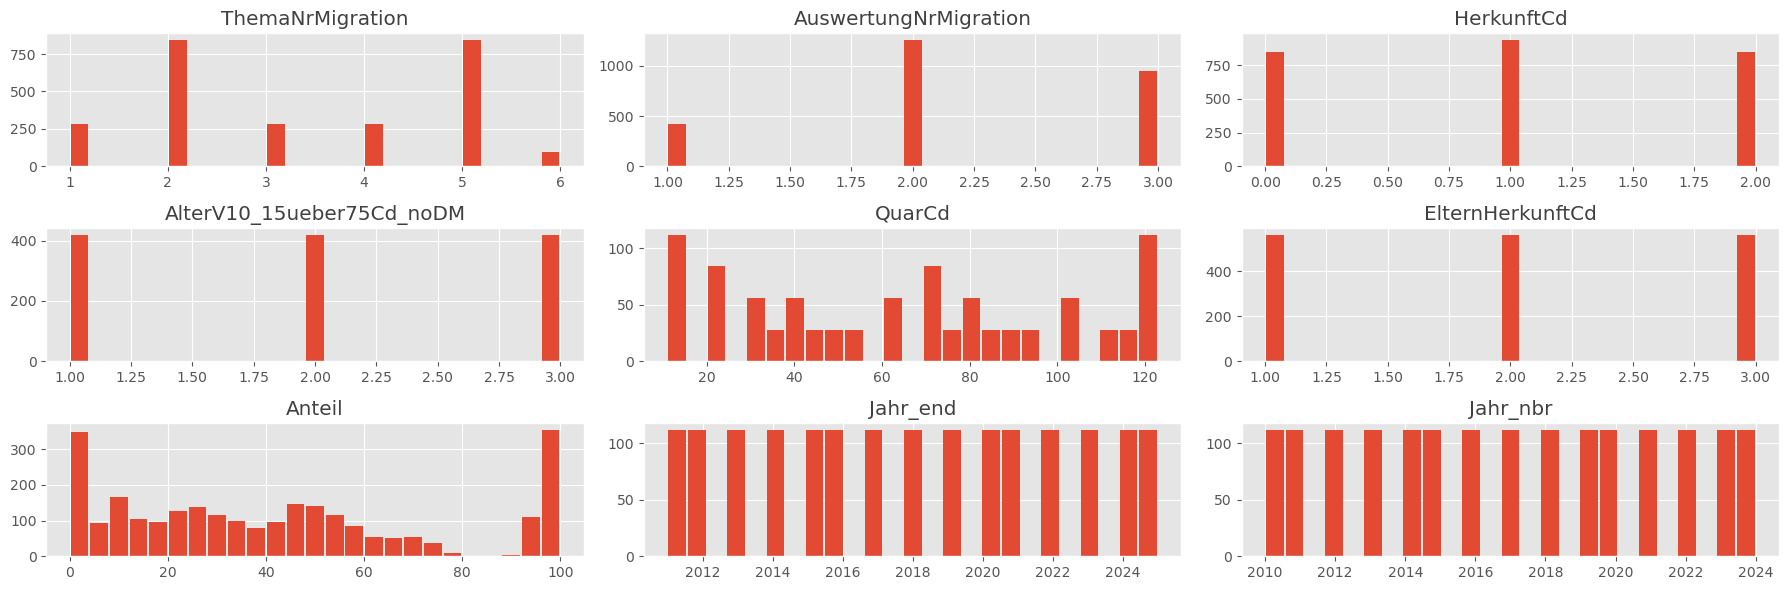

In [138]:
plt.style.use('ggplot')
params = {
    'text.color': (0.25, 0.25, 0.25),
    'figure.figsize': [18, 6],
   }
plt.rcParams.update(params)

try:
    data2betested.hist(bins=25, rwidth=0.9)
    plt.tight_layout()
    plt.show()
except:
    print("No numercial data to plot.") 

### Gibt es Duplikate?

In [139]:
# find duplicate rows
duplicate_rows = data2betested[data2betested.duplicated()]
duplicate_rows

,ThemaNrMigration,ThemaMigration,AuswertungNrMigration,AuswertungMigration,Zeitbezug,HerkunftCd,Herkunft,...,ElternHerkunftCd,ElternHerkunftLang,Anteil,Konfidenzintervall,Jahr_str,Jahr_end,Jahr_nbr
Jahr,,,,,,,,,,,,,,,


### Nullwerte und Missings?

In [140]:
data2betested.isnull().sum()

ThemaNrMigration                  0
ThemaMigration                    0
AuswertungNrMigration             0
AuswertungMigration               0
Zeitbezug                         0
HerkunftCd                        0
Herkunft                          0
AlterV10_15ueber75Cd_noDM      1372
AlterV10_15ueber75Lang_noDM    1372
QuarCd                         1680
QuarLang                       1680
ElternHerkunftCd                940
ElternHerkunftLang              940
Anteil                            0
Konfidenzintervall                0
Jahr_str                          0
Jahr_end                        952
Jahr_nbr                        952
dtype: int64

In [141]:
# check missing values with missingno
# https://github.com/ResidentMario/missingno
#import missingno as msno
#msno.matrix(data2betested, labels=True, sort='descending');
#msno.heatmap(data2betested)

### Gruppierungen

In [142]:
agg_thema = data2betested\
    .groupby(['ThemaNrMigration', 'ThemaMigration']) \
    .agg(med_AntBev=('Anteil', 'median')) \
    .sort_values('ThemaNrMigration', ascending=False) 
agg_thema.reset_index().head(3)

,ThemaNrMigration,ThemaMigration,med_AntBev
0,6,Anteil der Eingebürgerten an den Schweizer*innen,26
1,5,Geburtsort der Eltern,26
2,4,Mindestens ein Elternteil im Ausland geboren,65


In [143]:
agg_AuswMigr = data2betested\
    .groupby(['AuswertungNrMigration', 'AuswertungMigration']) \
    .agg(med_AntBev=('Anteil', 'median')) \
    .sort_values('AuswertungNrMigration', ascending=False) 
agg_AuswMigr.reset_index().head(3)

,AuswertungNrMigration,AuswertungMigration,med_AntBev
0,3,nach Quartier,40
1,2,nach Alter,35
2,1,Total,40


In [144]:
agg_herk = data2betested\
    .groupby(['HerkunftCd', 'Herkunft']) \
    .agg(med_AntBev=('Anteil', 'median')) \
    .sort_values('HerkunftCd', ascending=False) 
agg_herk.reset_index().head(30)

,HerkunftCd,Herkunft,med_AntBev
0,2,Ausländer*in,94
1,1,Schweizer*in,27
2,0,Total,45


In [145]:
agg_alterk = data2betested\
    .groupby(['AlterV10_15ueber75Cd_noDM', 'AlterV10_15ueber75Lang_noDM']) \
    .agg(med_AntBev=('Anteil', 'median')) \
    .sort_values('AlterV10_15ueber75Cd_noDM', ascending=False) 
agg_alterk.reset_index().head(30)

,AlterV10_15ueber75Cd_noDM,AlterV10_15ueber75Lang_noDM,med_AntBev
0,3,60 und älter,31
1,2,40 bis 59,41
2,1,15 bis 39,36


In [146]:
agg_herkElt = data2betested\
    .groupby(['ElternHerkunftCd','ElternHerkunftLang']) \
    .agg(med_AntBev=('Anteil', 'median')) \
    .sort_values('ElternHerkunftCd', ascending=False) 
agg_herkElt.reset_index().head(30)

,ElternHerkunftCd,ElternHerkunftLang,med_AntBev
0,3,Eltern im Ausland geboren,52
1,3,"Mit Migrationshintergrund, zweite Generation",7
2,2,"Ein Elternteil in der Schweiz, der andere im A...",12
3,2,"Mit Migrationshintergrund, erste Generation",45
4,1,Eltern in der Schweiz geboren,35
5,1,Ohne Migrationshintergrund,46


In [147]:
data2betested.columns

Index(['ThemaNrMigration', 'ThemaMigration', 'AuswertungNrMigration', 'AuswertungMigration',
       'Zeitbezug', 'HerkunftCd', 'Herkunft', 'AlterV10_15ueber75Cd_noDM',
       'AlterV10_15ueber75Lang_noDM', 'QuarCd', 'QuarLang', 'ElternHerkunftCd',
       'ElternHerkunftLang', 'Anteil', 'Konfidenzintervall', 'Jahr_str', 'Jahr_end', 'Jahr_nbr'],
      dtype='object')

### Pivotiere

In [148]:
pivoted_df = data2betested.query("AuswertungNrMigration==1")\
.pivot_table(
    index=['ThemaNrMigration', 'ThemaMigration', 'HerkunftCd', 'Herkunft','ElternHerkunftCd',
       'ElternHerkunftLang'],
    columns= ('Jahr_nbr'),
    values=['Anteil'],
    aggfunc='median'
)

# Sortieren nach der Aggregation 
pivoted_df = pivoted_df.sort_values(by=pivoted_df.index[-1], axis=1, ascending=False)

# Sortieren der Zeilen (Jahre) in absteigender Reihenfolge
#pivoted_df = pivoted_df.sort_index(ascending=True)

# Anzeigen des Ergebnisses
pivoted_df.reset_index()

ThemaNrMigration                                 ThemaMigration HerkunftCd      Herkunft  \
Jahr_nbr                                                                                            
0                       2  Migrationsstatus, erste und zweite Generation          0         Total   
1                       2  Migrationsstatus, erste und zweite Generation          0         Total   
2                       2  Migrationsstatus, erste und zweite Generation          0         Total   
3                       2  Migrationsstatus, erste und zweite Generation          1  Schweizer*in   
4                       2  Migrationsstatus, erste und zweite Generation          1  Schweizer*in   
5                       2  Migrationsstatus, erste und zweite Generation          1  Schweizer*in   
6                       2  Migrationsstatus, erste und zweite Generation          2  Ausländer*in   
7                       2  Migrationsstatus, erste und zweite Generation          2  Ausländer*in   
8                       2  Migrationsstatus, erste und zweite Generation          2  Ausländer*in   
9                       5                          Geburtsort der Eltern          0         Total   
10                      5                          Geburtsort der Eltern          0         Total   
11                      5                          Geburtsort der Eltern          0         Total   
12                      5                          Geburtsort der Eltern          1  Schweizer*in   
13                      5                          Geburtsort der Eltern          1  Schweizer*in   
14                      5                          Geburtsort der Eltern          1  Schweizer*in   
15                      5                          Geburtsort der Eltern          2  Ausländer*in   
16                      5                          Geburtsort der Eltern          2  Ausländer*in   
17                      5                          Geburtsort der Eltern          2  Ausländer*in   

         ElternHerkunftCd                                 ElternHerkunftLang Anteil  ...       \
Jahr_nbr                                                                       2010  ... 2021   
0                       1                         Ohne Migrationshintergrund     51  ...   45   
1                       2        Mit Migrationshintergrund, erste Generation     42  ...   46   
2                       3       Mit Migrationshintergrund, zweite Generation      8  ...    8   
3                       1                         Ohne Migrationshintergrund     74  ...   68   
4                       2        Mit Migrationshintergrund, erste Generation     18  ...   22   
5                       3       Mit Migrationshintergrund, zweite Generation      8  ...   10   
6                       1                         Ohne Migrationshintergrund      0  ...    0   
7                       2        Mit Migrationshintergrund, erste Generation     94  ...   96   
8                       3       Mit Migrationshintergrund, zweite Generation      6  ...    4   
9                       1                      Eltern in der Schweiz geboren     42  ...   35   
10                      2  Ein Elternteil in der Schweiz, der andere im A...     12  ...   12   
11                      3                          Eltern im Ausland geboren     47  ...   53   
12                      1                      Eltern in der Schweiz geboren     60  ...   53   
13                      2  Ein Elternteil in der Schweiz, der andere im A...     16  ...   17   
14                      3                          Eltern im Ausland geboren     23  ...   30   
15                      1                      Eltern in der Schweiz geboren      0  ...    0   
16                      2  Ein Elternteil in der Schweiz, der andere im A...      1  ...    1   
17                      3                          Eltern im Ausland geboren     99  ...   98   

                                        
Jahr_n

### Visualisierungen nach Zeitausschnitten

#### Entwicklungen

In [149]:
data2betested.reset_index().columns

Index(['Jahr', 'ThemaNrMigration', 'ThemaMigration', 'AuswertungNrMigration',
       'AuswertungMigration', 'Zeitbezug', 'HerkunftCd', 'Herkunft', 'AlterV10_15ueber75Cd_noDM',
       'AlterV10_15ueber75Lang_noDM', 'QuarCd', 'QuarLang', 'ElternHerkunftCd',
       'ElternHerkunftLang', 'Anteil', 'Konfidenzintervall', 'Jahr_str', 'Jahr_end', 'Jahr_nbr'],
      dtype='object')

In [150]:
the_query="ThemaNrMigration == 1 & AuswertungNrMigration == 1 & HerkunftCd!=0"

In [163]:
#myAgg = data2betested.loc["2008-11-30":"2021-10-31"]
myAgg1 = data2betested\
    .query("ThemaNrMigration == 4 & AuswertungNrMigration == 1 & HerkunftCd!=0") \
    .groupby(['Jahr', 'ThemaNrMigration', 'ThemaMigration', 'AuswertungNrMigration',
       'AuswertungMigration', 'Zeitbezug', 'HerkunftCd', 'Herkunft']) \
    .agg(mean_Ant=('Anteil', 'mean')) \
    .sort_values('Jahr', ascending=True) 

myAgg1.reset_index().head(3)

,Jahr,ThemaNrMigration,ThemaMigration,AuswertungNrMigration,AuswertungMigration,Zeitbezug,HerkunftCd,Herkunft,mean_Ant
0,2010-01-01,4,Mindestens ein Elternteil im Ausland geboren,1,Total,2010 – 2024,1,Schweizer*in,40
1,2010-01-01,4,Mindestens ein Elternteil im Ausland geboren,1,Total,2010 – 2024,2,Ausländer*in,100
2,2011-01-01,4,Mindestens ein Elternteil im Ausland geboren,1,Total,2010 – 2024,1,Schweizer*in,40


In [172]:
grafik1 = mypy_dv.plot_altair_multiline_highlight(
    data = myAgg1.reset_index().sort_values('HerkunftCd', ascending=True)
    ,x = 'Jahr:T'
    ,y = 'mean_Ant:Q'
    ,x_beschriftung = 'Jahr'
    , y_beschriftung = 'Anteil'
    ,category = "Herkunft:N"
    ,category_beschriftung= 'Legende:'
    ,x_sort = None
    ,palette_scheme = None # 'turbo','viridis','category20b','category20c', 'tableau20', 'sinebow', 'rainbow, 'dark2', 'inferno',
    ,custom_palette = zuericolors_qual12br
    ,line_width = 1.1                 
    ,warning_status = "ignore" #always or ignore
    ,myTitle="Entwicklung: 'Mindestens ein Elternteil im Ausland geboren', seit "+data_min_date 
)
grafik1

alt.LayerChart(...)

#### Barcharts mit Seaborn

In [153]:
#help(sns.catplot)   

# #Stile for the following sns graphs
sns.set_theme(style="whitegrid")

##### Stacked Bar Chart

In [154]:
# Daten vorbereiten

data_pivoted = data2betested.query("ThemaNrMigration==2 & HerkunftCd!=0")\
.pivot_table(
    index=['Jahr_nbr'],
    columns= ('ElternHerkunftLang'),
    values=['Anteil'],
    aggfunc='median'
)

# Sortieren nach der Aggregation 
data_pivoted = data_pivoted.sort_values(by=data_pivoted.index[-1], axis=1, ascending=False)

# Sortieren der Zeilen (Jahre) in absteigender Reihenfolge
#data_pivoted = data_pivoted.sort_index(ascending=True)

# Anzeigen des Ergebnisses
data_pivoted.reset_index()

Jahr_nbr                                      Anteil  \
ElternHerkunftLang          Mit Migrationshintergrund, erste Generation   
0                      2010                                          58   
1                      2011                                          58   
2                      2012                                          60   
3                      2013                                          60   
4                      2014                                          59   
5                      2015                                          60   
6                      2016                                          61   
7                      2017                                          61   
8                      2018                                          61   
9                      2019                                          62   
10                     2020                                          64   
11                     2021                                          63   
12                     2022                                          63   
13                     2023                                          64   
14                     2024                                          63   

                                                                                            
ElternHerkunftLang Ohne Migrationshintergrund Mit Migrationshintergrund, zweite Generation  
0                                          34                                            7  
1                                          34                                            6  
2                                          33                                            6  
3                                          32                                            7  
4                                          33                                            6  
5                                          32                                            6  
6                                          32                                            6  
7                                          31                                            5  
8                                          31                                            6  
9                                          30                                            5  
10                                         28                                            4  
11                                         30                                            4  
12                                         29                                            5  
13                                         29                                            4  
14                                         30                                            4

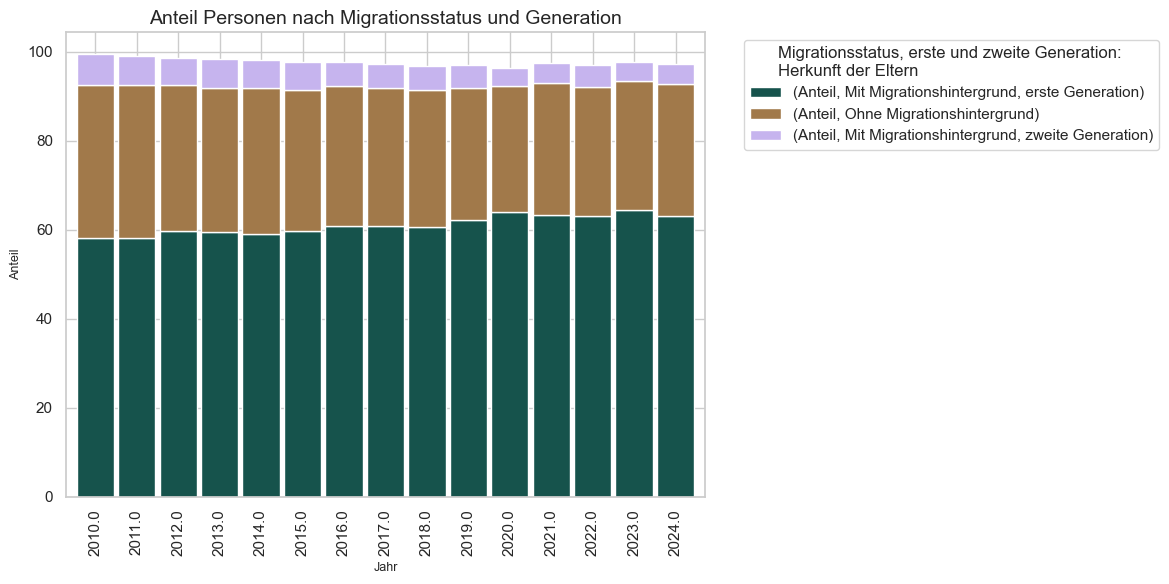

In [155]:
# Farbpalette erstellen
colors = sns.color_palette("cubehelix", n_colors=len(data_pivoted.columns)) #"flare" / "vlag" / "icefire" / "Spectral"
# Figur und Achsen erstellen
fig, ax = plt.subplots(figsize=(12, 6))
# Gestapeltes Balkendiagramm zeichnen
data_pivoted.plot(
    kind='bar', # barh für horizontale Balken, bar für vertikale Balken
    stacked=True, 
    ax=ax, 
    color=colors,
    width=0.9
    )
# Titel hinzufügen
plt.title('Anteil Personen nach Migrationsstatus und Generation', fontsize=14)
# Achsenbeschriftungen anpassen
ax.set_xlabel('Jahr', fontsize=9)
ax.set_ylabel('Anteil', fontsize=9)

# Legende anpassen
plt.legend(title='Migrationsstatus, erste und zweite Generation: \nHerkunft der Eltern', bbox_to_anchor=(1.05, 1), loc='upper left')
# Layout anpassen
plt.tight_layout()
# Diagramm anzeigen
plt.show()

#### Treemaps

**Funktion zum einfärben**

Muss ich noch als Funktion umsetzen 

In [156]:
# Extrahiere die Top-Fahrzeugmarken
auspraegung = data2betested['ElternHerkunftLang'].unique().tolist()
# Verfügbare Farben
verfügbare_farben_zuericolors = zuericolors_qual12da+zuericolors_qual12br+zuericolors_qual12+zuericolors_div9ntr

# Erstelle das Farben-Dictionary
farben_dict_zc = {'(?)':'lightgrey'}
for index, x in enumerate(auspraegung):
    farben_dict_zc[x] = verfügbare_farben_zuericolors[index % len(verfügbare_farben_zuericolors)]

# Das resultierende Farben-Dictionary
print(farben_dict_zc)
#print(verfügbare_farben_zuericolors)

{'(?)': 'lightgrey', nan: '#0017BF', 'Eltern in der Schweiz geboren': '#0072D7', 'Ohne Migrationshintergrund': '#00A5D2', 'Eltern im Ausland geboren': '#5E359A', 'Mit Migrationshintergrund, zweite Generation': '#BA0062', 'Mit Migrationshintergrund, erste Generation': '#DA5563', 'Ein Elternteil in der Schweiz, der andere im Ausland geboren': '#00615D'}


##### Anteil Personen nach Migrationsstatus

In [157]:
data2betested.columns
data2betested.query("ThemaNrMigration == 1 & AuswertungNrMigration == 1 & HerkunftCd!=0").reset_index()

,Jahr,ThemaNrMigration,ThemaMigration,AuswertungNrMigration,AuswertungMigration,Zeitbezug,HerkunftCd,...,ElternHerkunftCd,ElternHerkunftLang,Anteil,Konfidenzintervall,Jahr_str,Jahr_end,Jahr_nbr
0,2010-01-01,1,Personen mit Migrationshintergrund,1,Total,2010 – 2024,1,...,NaN,NaN,26,25.1 bis 26.1,2010-01-01,2010-12-31,2010
1,2010-01-01,1,Personen mit Migrationshintergrund,1,Total,2010 – 2024,2,...,NaN,NaN,100,99.8 bis 99.9,2010-01-01,2010-12-31,2010
2,2011-01-01,1,Personen mit Migrationshintergrund,1,Total,2010 – 2024,1,...,NaN,NaN,25,23.8 bis 25.9,2011-01-01,2011-12-31,2011
3,2011-01-01,1,Personen mit Migrationshintergrund,1,Total,2010 – 2024,2,...,NaN,NaN,100,99.8 bis 100.0,2011-01-01,2011-12-31,2011
4,2012-01-01,1,Personen mit Migrationshintergrund,1,Total,2010 – 2024,2,...,NaN,NaN,100,99.8 bis 100.0,2012-01-01,2012-12-31,2012
5,2012-01-01,1,Personen mit Migrationshintergrund,1,Total,2010 – 2024,1,...,NaN,NaN,28,27.1 bis 29.2,2012-01-01,2012-12-31,2012
6,2013-01-01,1,Personen mit Migrationshintergrund,1,Total,2010 – 2024,1,...,NaN,NaN,27,26.3 bis 28.4,2013-01-01,2013-12-31,2013
7,2013-01-01,1,Personen mit Migrationshintergrund,1,Total,2010 – 2024,2,...,NaN,NaN,100,99.7 bis 100.0,2013-01-01,2013-12-31,2013
8,2014-01-01,1,Personen mit Migrationshintergrund,1,Total,2010 – 2024,2,...,NaN,NaN,100,99.7 bis 100.0,2014-01-01,2014-12-31,2014
9,2014-01-01,1,Personen mit Migrationshintergrund,1,Total,2010 – 2024,1,...,NaN,NaN,28,26.7 bis 28.8,2014-01-01,2014-12-31,2014


In [173]:
the_query="ThemaNrMigration != 1 & AuswertungNrMigration != 8 & HerkunftCd!=0"

treeMap1 = mypy_dv.plot_px_treemap(
    data=data2betested.query(the_query).reset_index()
    ,levels=['ThemaMigration', 'AuswertungMigration','Zeitbezug','Herkunft']
    ,values="Anteil"
    ,color="ElternHerkunftLang"
    #, color_continuous_scale='Blues'
    ,color_discrete_map=farben_dict_zc
    ,height=400
    ,width=900               
    #,margin_val_bottom=25
    ,myHeaderTitle="Anteil Personen"
)
treeMap1

path: [<plotly.express._special_inputs.Constant object at 0x000001FF51E37BD0>, 'ThemaMigration', 'AuswertungMigration', 'Zeitbezug', 'Herkunft']
Typ von path: <class 'list'>


## ---------------------- hier Plausi beendet

**Sharepoint als gecheckt markieren!**

Record auf Sharepoint: **[Link](https://szhglobal.sharepoint.com/sites/ssz-spo-produkte/Lists/SASA_Outputs/DispForm.aspx?ID=472&e=295NOa)**

---------------------------------------------------------------------------